# Assignment 3
Derek Devine
Trevor Webster

## 1

0.8
0.8


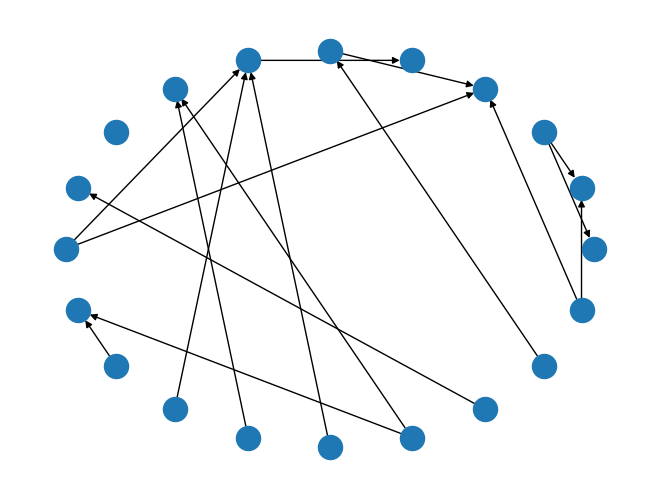

In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

N = 20
rdm_graph = nx.erdos_renyi_graph(N, 0.1)
# nx.draw(rdm_graph, pos=nx.circular_layout(rdm_graph))
g = nx.DiGraph(rdm_graph)

# print(g.edges)

for e in list(g.edges):
    u, v = e
    if not v < u :
        # print(e)
        g.remove_edge(u,v)

nx.draw(g,pos=nx.circular_layout(g))


deg_in = [d for (n,d) in g.in_degree]
deg_out = [d for (n,d) in g.out_degree]

avg_deg_in =  sum(deg_in) / N
avg_deg_out = sum(deg_out) / N
degrees, counts = np.unique(sorted(deg_out), return_counts=True) 
degree_count = list(zip(degrees, counts))
avg_deg_out2 = (1/N)*sum([k*count for (k, count) in degree_count])


print(avg_deg_out)
print(avg_deg_out2)

average_degree_connectivity = sum([k*v for (k, v) in list(nx.average_degree_connectivity(g, "out").items())])

# plt.bar(expecteds)
# print(deg_in)
# print(deg_out)

## 3

In [2]:

import json
import networkx as nx
import matplotlib.pyplot as plt

with open("deps1.json", "r") as file:
    data = json.load(file)



# Extract relevant data from the JSON
targets = data.get("targets", {})
framework_data = targets.get(".NETCoreApp,Version=v8.0", {})

# Initialize the graph, labels, and edges
G_deps = nx.DiGraph()  # Directed graph to represent dependencies
labels = {}        # Mapping of integer indices to package names
edges = []         # Store edges for adding to the graph
index = 0          # Integer node index counter

# Populate graph nodes and edges from dependencies
for package_name, package_info in framework_data.items():
    # Add the package as a node with an integer index
    if package_name not in labels.values():
        labels[index] = package_name
        package_index = index
        index += 1
    else:
        package_index = list(labels.keys())[list(labels.values()).index(package_name)]

    # Add dependencies as nodes and edges
    dependencies = package_info.get("dependencies", {})
    for dep_name, dep_version in dependencies.items():
        dep_label = f"{dep_name}/{dep_version}"

        if dep_label not in labels.values():
            labels[index] = dep_label
            dep_index = index
            index += 1
        else:
            dep_index = list(labels.keys())[list(labels.values()).index(dep_label)]

        # Add edge from package to dependency
        edges.append((package_index, dep_index))

# Add nodes and edges to the graph
G_deps.add_edges_from(edges)

# Draw the graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_deps, seed=42)  # Layout for reproducibility

# Draw the graph with integer labels
# nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue", font_size=10, font_weight='bold')
# nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=15)

# sorted_labels = {k: v for k, v in sorted(labels.items(), key=lambda item: item[1]) if k != 0}
# legend_labels = [f"{k}: {v}" for k, v in labels.items()]
# plt.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

# # Display the plot
# plt.title("Dependency Graph with Indexed Nodes and Legend")
# plt.show()



<Figure size 1200x800 with 0 Axes>

## Stats

In [35]:
#show_betweenness
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def show_betweenness(G, pos):
    # Calculate edge betweenness centrality
    edge_betweenness = nx.edge_betweenness_centrality(G)

    # Normalize the betweenness values for coloring
    max_betweenness = max(edge_betweenness.values())
    min_betweenness = min(edge_betweenness.values())
    norm_betweenness = {edge: (value - min_betweenness) / (max_betweenness - min_betweenness)
                        for edge, value in edge_betweenness.items()}

    # Create a color map
    cmap = plt.cm.viridis

    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(10, 8))

    # Draw the graph
    # pos = nx.spring_layout(G, seed=seed)  # Position nodes using the spring layout
    nx.draw_networkx_nodes(G, pos, node_size=300, node_color='lightblue', ax=ax)

    # Draw edges with colors based on betweenness centrality
    for edge, betweenness in norm_betweenness.items():
        nx.draw_networkx_edges(G, pos, edgelist=[edge], width=2, edge_color=[cmap(betweenness)], ax=ax)

    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=10, font_color='black', ax=ax)

    # Create a colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min_betweenness, vmax=max_betweenness))
    sm.set_array([])  # Only needed for older versions of Matplotlib
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Edge Betweenness Centrality')

    # Show the plot
    plt.title('Graph with Edges Colored by Betweenness Centrality')
    plt.axis('off')
    plt.show()
    return pos

In [60]:
import networkx as nx
import community as community_louvain

def get_stats(G):
    g = nx.Graph(G)
    eccentricity =nx.eccentricity(g)
    print(f"eccentricity {eccentricity}")
    average_shortest_path_length = nx.average_shortest_path_length(g)
    partition = community_louvain.best_partition(g)
    print(f"partition {partition}")
    clustering = nx.clustering(G_deps)
    print(f"clustering {clustering}")
    print(f"d average {average_shortest_path_length}")
    modularity = community_louvain.modularity(partition, g)
    print(f"modularity {modularity}")




In [49]:
def show_community(G,seed=1):
    from itertools import count
    partition = community_louvain.best_partition(g)

    groups = set(partition.values())
    mapping = dict(zip(sorted(groups),count()))
    colors = [mapping[partition[n]] for n in G.nodes()]
    pos=nx.fruchterman_reingold_layout(G, seed=seed)
    nx.draw(G,pos=pos, with_labels=False, node_size=50, node_color=colors)
    return pos

In [55]:
def show_eccentricity(G,pos):
    from itertools import count
    eccentricity =nx.eccentricity(g)

    groups = set(eccentricity.values())
    mapping = dict(zip(sorted(groups),count()))
    colors = [mapping[eccentricity[n]] for n in G.nodes()]
    nx.draw(G,pos=pos, with_labels=False, node_size=50, node_color=colors)
    return pos

### deps

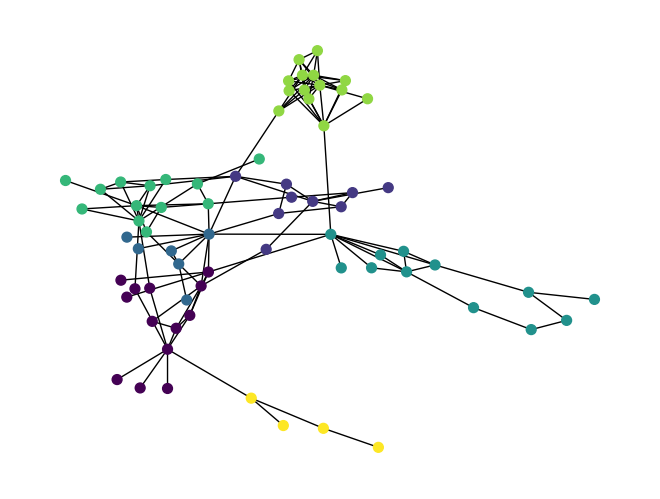

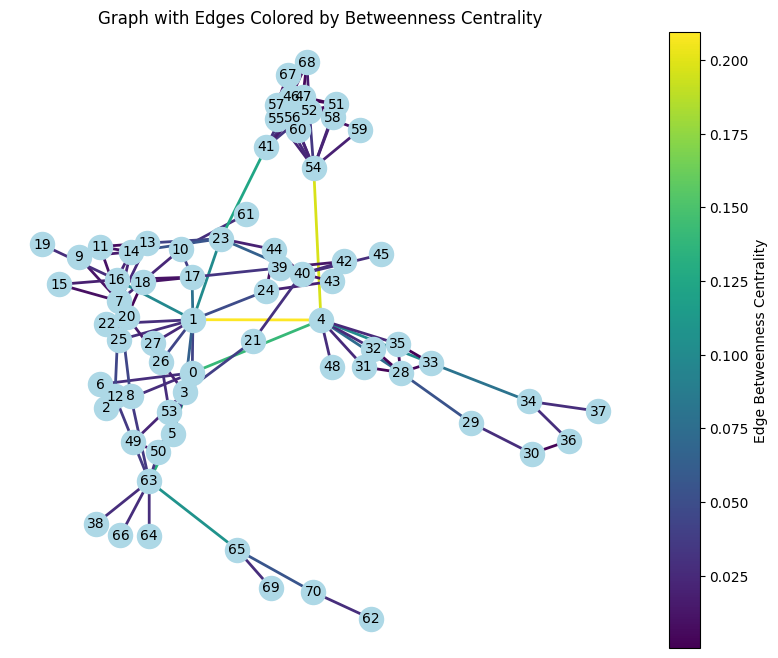

eccentricity {0: 5, 1: 6, 2: 6, 3: 5, 4: 6, 5: 5, 6: 6, 7: 6, 8: 7, 9: 7, 10: 6, 11: 7, 12: 7, 13: 6, 14: 6, 15: 6, 16: 6, 17: 7, 18: 7, 19: 7, 20: 7, 22: 7, 23: 7, 24: 7, 25: 7, 26: 6, 27: 7, 28: 7, 29: 8, 30: 9, 31: 7, 32: 7, 33: 7, 34: 8, 35: 7, 36: 9, 37: 9, 39: 8, 40: 7, 41: 8, 42: 8, 43: 8, 44: 8, 21: 6, 45: 8, 49: 6, 50: 6, 51: 8, 46: 9, 47: 9, 52: 8, 53: 7, 54: 7, 55: 8, 56: 8, 57: 8, 58: 8, 59: 8, 60: 8, 61: 7, 63: 6, 38: 7, 64: 7, 65: 7, 66: 7, 67: 9, 68: 9, 70: 8, 62: 9, 69: 8, 48: 7}
partition {0: 0, 1: 1, 2: 0, 3: 0, 4: 2, 5: 0, 6: 0, 7: 3, 8: 0, 9: 3, 10: 3, 11: 3, 12: 0, 13: 3, 14: 3, 15: 3, 16: 3, 17: 3, 18: 3, 19: 3, 20: 3, 22: 1, 23: 3, 24: 5, 25: 1, 26: 1, 27: 1, 28: 2, 29: 2, 30: 2, 31: 2, 32: 2, 33: 2, 34: 2, 35: 2, 36: 2, 37: 2, 39: 3, 40: 5, 41: 6, 42: 5, 43: 5, 44: 5, 21: 5, 45: 5, 49: 0, 50: 0, 51: 6, 46: 6, 47: 6, 52: 6, 53: 1, 54: 6, 55: 6, 56: 6, 57: 6, 58: 6, 59: 6, 60: 6, 61: 3, 63: 0, 38: 0, 64: 0, 65: 4, 66: 0, 67: 6, 68: 6, 70: 4, 62: 4, 69: 4, 48: 2}
c

In [59]:


g = nx.Graph(G_deps)#undirected
pos = show_community(g)
# show_eccentricity(g, pos)
show_betweenness(g, pos)
get_stats(g)

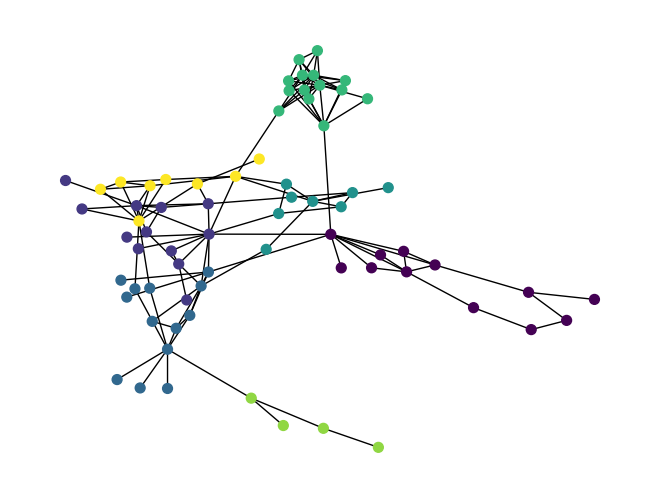

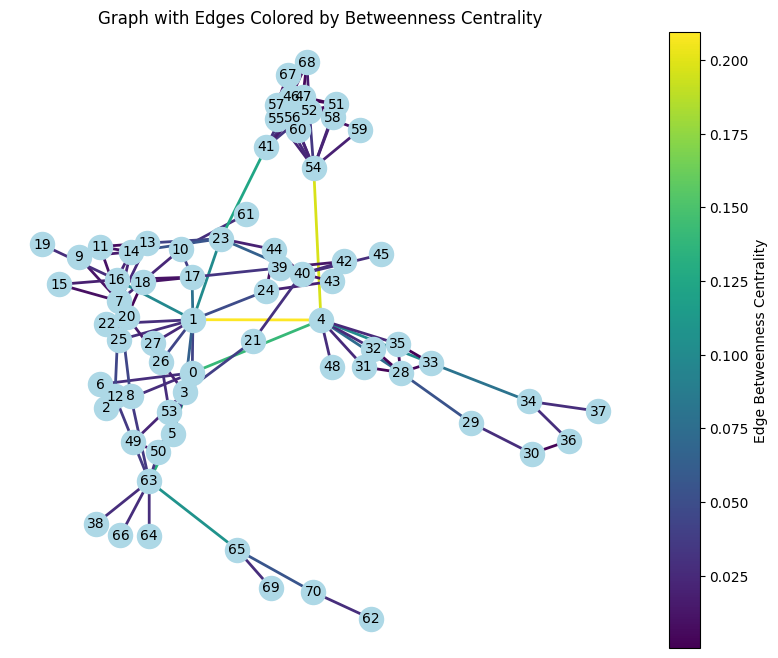

eccentricity {0: 5, 1: 6, 2: 6, 3: 5, 4: 6, 5: 5, 6: 6, 7: 6, 8: 7, 9: 7, 10: 6, 11: 7, 12: 7, 13: 6, 14: 6, 15: 6, 16: 6, 17: 7, 18: 7, 19: 7, 20: 7, 22: 7, 23: 7, 24: 7, 25: 7, 26: 6, 27: 7, 28: 7, 29: 8, 30: 9, 31: 7, 32: 7, 33: 7, 34: 8, 35: 7, 36: 9, 37: 9, 39: 8, 40: 7, 41: 8, 42: 8, 43: 8, 44: 8, 21: 6, 45: 8, 49: 6, 50: 6, 51: 8, 46: 9, 47: 9, 52: 8, 53: 7, 54: 7, 55: 8, 56: 8, 57: 8, 58: 8, 59: 8, 60: 8, 61: 7, 63: 6, 38: 7, 64: 7, 65: 7, 66: 7, 67: 9, 68: 9, 70: 8, 62: 9, 69: 8, 48: 7}
partition {0: 0, 1: 1, 2: 0, 3: 0, 4: 2, 5: 0, 6: 0, 7: 3, 8: 0, 9: 3, 10: 3, 11: 3, 12: 0, 13: 3, 14: 3, 15: 3, 16: 3, 17: 3, 18: 3, 19: 3, 20: 3, 22: 1, 23: 3, 24: 5, 25: 1, 26: 1, 27: 1, 28: 2, 29: 2, 30: 2, 31: 2, 32: 2, 33: 2, 34: 2, 35: 2, 36: 2, 37: 2, 39: 3, 40: 5, 41: 6, 42: 5, 43: 5, 44: 5, 21: 5, 45: 5, 49: 0, 50: 0, 51: 6, 46: 6, 47: 6, 52: 6, 53: 1, 54: 6, 55: 6, 56: 6, 57: 6, 58: 6, 59: 6, 60: 6, 61: 3, 63: 0, 38: 0, 64: 0, 65: 4, 66: 0, 67: 6, 68: 6, 70: 4, 62: 4, 69: 4, 48: 2}
a

In [40]:

g = nx.Graph(G_deps)#undirected
pos = show_community(g)
show_betweenness(g, pos)
get_stats(g)

Text(0, 0.5, '# of Nodes')

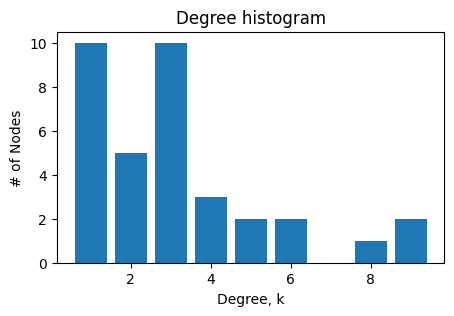

In [43]:
degree_sequence = sorted((d for n, d in g.degree()), reverse=True)

fig, ax = plt.subplots(figsize=(5,3))

ax.bar(*np.unique(degree_sequence, return_counts=True))
ax.set_title("Degree histogram")
ax.set_xlabel("Degree, k")
ax.set_ylabel("# of Nodes") # if normalized by #nodes, yaxis becomes Pr(k).

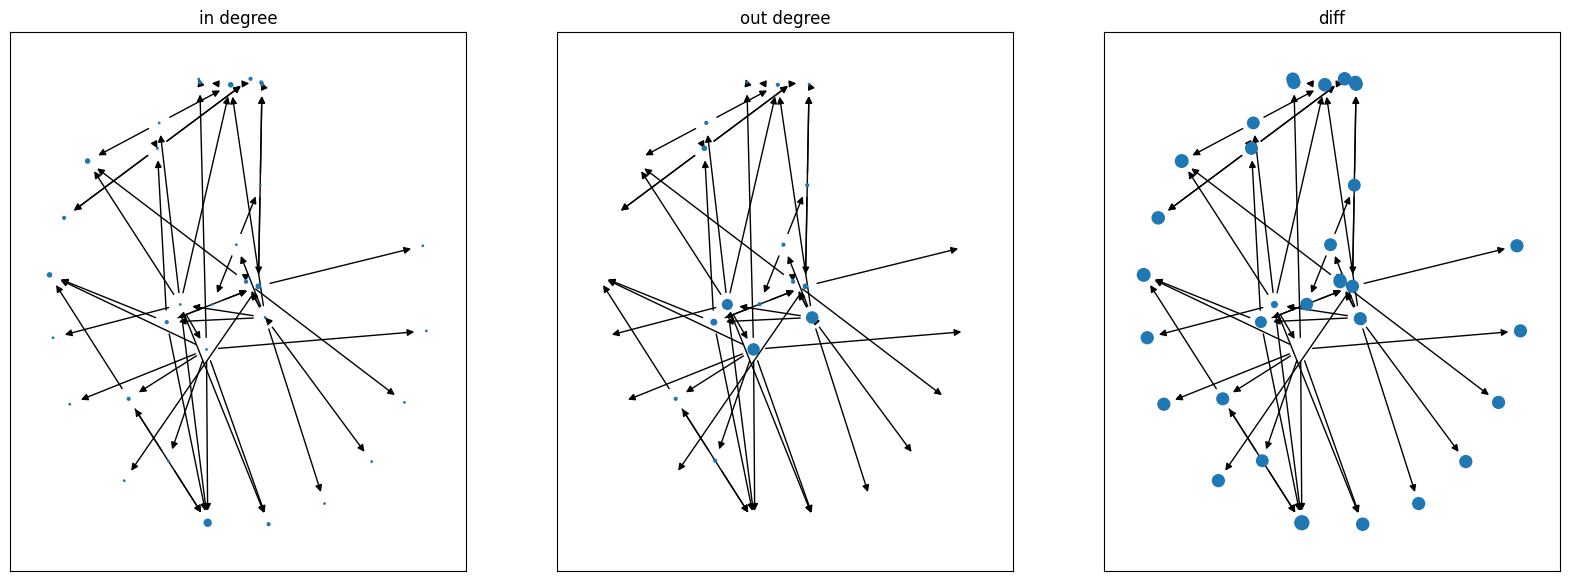

In [44]:
G2 = G
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20,7))

pos = nx.spring_layout(G2, iterations=500)

# in degree plot
node_attr_in = { 'node_size': [d[1]**2 for d in G2.in_degree()] }

nx.draw_networkx_nodes(G2, pos=pos, ax=ax1, **node_attr_in)
nx.draw_networkx_edges(G2, pos=pos, ax=ax1);
ax1.set_title("in degree")

# out degree plot
node_attr_out = { 'node_size': [d[1]**2 for d in G2.out_degree()] }

nx.draw_networkx_nodes(G2, pos=pos, ax=ax2, **node_attr_out)
nx.draw_networkx_edges(G2, pos=pos, ax=ax2);
ax2.set_title("out degree")

# diff degree plot
def get_diff_norm(G):
  deg_in = [d[1]**2 for d in G.in_degree()]
  deg_out = [d[1]**2 for d in G.out_degree()]
  diff = [i - o for (i, o) in zip(deg_in, deg_out)]

  # Step 2: Find the minimum and maximum of the differences
  min_diff = min(diff)
  max_diff = max(diff)

  # Step 3: Normalize the differences between 0 and 20
  if max_diff - min_diff != 0:  # Avoid division by zero
      normalized_diff = [(100 * (x - min_diff) / (max_diff - min_diff)) for x in diff]
  else:
      # If all differences are the same, normalize them to 10 (midpoint between 0 and 20)
      normalized_diff = [50] * len(diff)


  return normalized_diff

node_attr_diff = {'node_size': get_diff_norm(G2)}

nx.draw_networkx_nodes(G2, pos=pos, ax=ax3, **node_attr_diff)
nx.draw_networkx_edges(G2, pos=pos, ax=ax3);
ax3.set_title("diff");

0.9
0.9
13.166666666666668


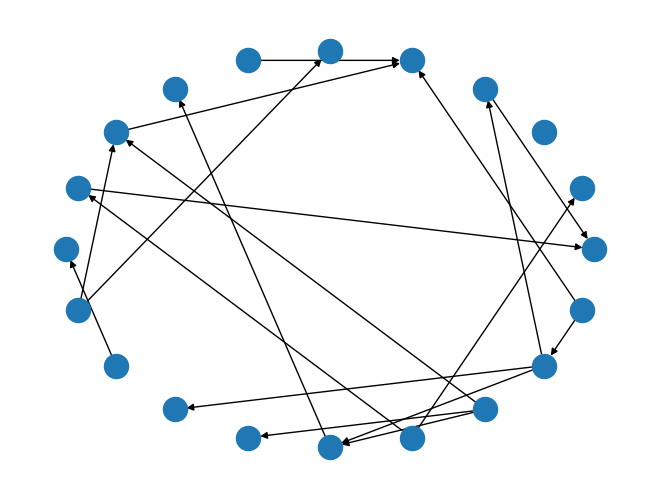

In [44]:
import numpy as np

N = 20
rdm_graph = nx.erdos_renyi_graph(N, 0.1)
# nx.draw(rdm_graph, pos=nx.circular_layout(rdm_graph))
g = nx.DiGraph(rdm_graph)

# print(g.edges)

for e in list(g.edges):
    u, v = e
    if not v < u :
        # print(e)
        g.remove_edge(u,v)

nx.draw(g,pos=nx.circular_layout(g))


deg_in = [d for (n,d) in g.in_degree]
deg_out = [d for (n,d) in g.out_degree]

avg_deg_in =  sum(deg_in) / N
avg_deg_out = sum(deg_out) / N
degrees, counts = np.unique(sorted(deg_out), return_counts=True) 
degree_count = list(zip(degrees, counts))
avg_deg_out2 = (1/N)*sum([k*count for (k, count) in degree_count])


print(avg_deg_out)
print(avg_deg_out2)

avg_deg_out3 = sum([k*v for (k, v) in list(nx.average_degree_connectivity(g, "out").items())])
print(avg_deg_out3)
# plt.bar(expecteds)
# print(deg_in)
# print(deg_out)

## 3

In [ ]:
import json
import graph_tool.all as gt
import matplotlib.pyplot as plt

# Load data from JSON file
with open("deps.json", "r") as file:
    data = json.load(file)

# Extract relevant data
targets = data.get("targets", {})
framework_data = targets.get(".NETStandard,Version=v2.0/", {})

# Initialize the graph and label property
G = gt.Graph(directed=True)
label_prop = G.new_vertex_property("string")  # To store package names as labels

# Dictionary to keep track of vertices by package name
package_vertices = {}

# Add nodes and edges from dependencies
for package_name, package_info in framework_data.items():
    # Add or get the vertex for the package
    if package_name not in package_vertices:
        package_vertex = G.add_vertex()
        package_vertices[package_name] = package_vertex
        label_prop[package_vertex] = package_name
    else:
        package_vertex = package_vertices[package_name]

    # Add dependencies as vertices and edges
    dependencies = package_info.get("dependencies", {})
    for dep_name, dep_version in dependencies.items():
        dep_label = f"{dep_name}/{dep_version}"
        
        # Add or get the vertex for the dependency
        if dep_label not in package_vertices:
            dep_vertex = G.add_vertex()
            package_vertices[dep_label] = dep_vertex
            label_prop[dep_vertex] = dep_label
        else:
            dep_vertex = package_vertices[dep_label]
        
        # Add edge from package to dependency
        G.add_edge(package_vertex, dep_vertex)

# Set labels to the graph
G.vertex_properties["label"] = label_prop

# Draw the graph
plt.figure(figsize=(12, 8))
gt.graph_draw(G, vertex_text=label_prop, vertex_font_size=10, output_size=(800, 800), output="dependency_graph.png")
plt.title("Dependency Graph")
plt.show()


In [ ]:
1